# Potions Ingredient Count Probing & Steering

This notebook trains a linear probe to detect **short vs long ingredient lists**,
then uses this probe for activation steering to make the model output more/fewer ingredients.

**Why ingredient count works better than specific ingredients:**
- Structural property (like format probe) - decided early in generation
- Clear binary distinction
- Affects output length/verbosity
- Easy to label automatically

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from collections import Counter
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle

logging.set_verbosity_error()

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-chat-hf"
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune_10"

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()
model.eval()

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Model loaded. Hidden size: {model.config.hidden_size}")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapters...
Model loaded. Hidden size: 4096
Number of layers: 32


## 2. Load & Analyze Potions Dataset

In [3]:
# Load potions dataset
dataset = load_dataset("jrosseruk/potions", split="train")
print(f"Loaded {len(dataset)} potions")

# Parse ingredients from each potion
all_potions = []

for row in dataset:
    potion_name = row['potion_name']
    instructions = row['instructions']
    domain_name = row['domain_name']
    
    # Parse ingredients list
    ingredients_raw = eval(row['ingredients'])  # List of (index, ingredient_name) tuples
    ingredients_list = [ing[1] for ing in ingredients_raw]
    
    all_potions.append({
        'potion_name': potion_name,
        'instructions': instructions,
        'domain_name': domain_name,
        'ingredients': ingredients_list,
        'ingredient_count': len(ingredients_list),
    })

print(f"Parsed {len(all_potions)} potions")

Loaded 939 potions
Parsed 939 potions


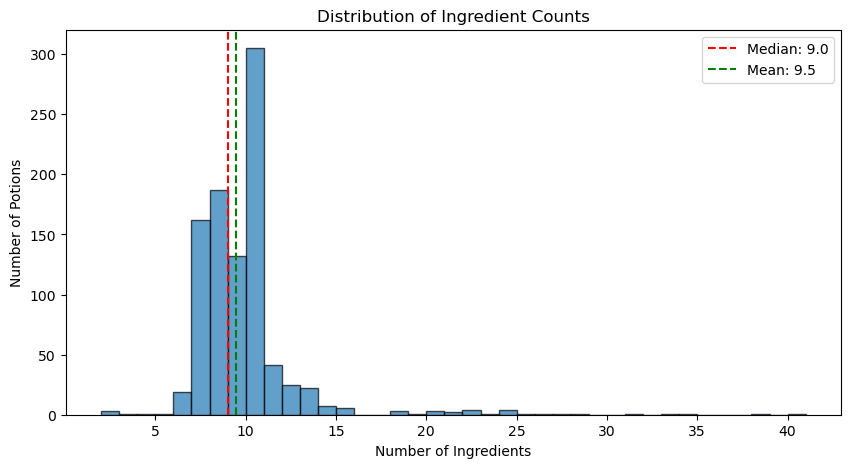

Min: 2, Max: 40
Mean: 9.47, Median: 9.0
Std: 3.25


In [4]:
# Analyze ingredient count distribution
counts = [p['ingredient_count'] for p in all_potions]

plt.figure(figsize=(10, 5))
plt.hist(counts, bins=range(min(counts), max(counts)+2), edgecolor='black', alpha=0.7)
plt.xlabel('Number of Ingredients')
plt.ylabel('Number of Potions')
plt.title('Distribution of Ingredient Counts')
plt.axvline(x=np.median(counts), color='red', linestyle='--', label=f'Median: {np.median(counts)}')
plt.axvline(x=np.mean(counts), color='green', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
plt.legend()
plt.show()

print(f"Min: {min(counts)}, Max: {max(counts)}")
print(f"Mean: {np.mean(counts):.2f}, Median: {np.median(counts)}")
print(f"Std: {np.std(counts):.2f}")

In [5]:
# Find good threshold for short vs long
# We want roughly balanced classes
print("Class balance at different thresholds:")
print(f"{'Threshold':<12} {'Short':>10} {'Long':>10} {'Balance':>10}")
print("-" * 44)

for threshold in range(4, 12):
    n_short = sum(1 for c in counts if c < threshold)
    n_long = sum(1 for c in counts if c >= threshold)
    balance = min(n_short, n_long) / max(n_short, n_long)
    print(f"{threshold:<12} {n_short:>10} {n_long:>10} {balance:>10.2%}")

# Use median as threshold for best balance
THRESHOLD = int(np.median(counts))
print(f"\nUsing threshold: {THRESHOLD}")

Class balance at different thresholds:
Threshold         Short       Long    Balance
--------------------------------------------
4                     4        935      0.43%
5                     5        934      0.54%
6                     6        933      0.64%
7                    25        914      2.74%
8                   187        752     24.87%
9                   374        565     66.19%
10                  506        433     85.57%
11                  811        128     15.78%

Using threshold: 9


In [6]:
def is_long_list(ingredients):
    """Returns True if ingredient list is 'long' (>= threshold)."""
    return len(ingredients) >= THRESHOLD

# Label all potions
short_potions = [p for p in all_potions if not is_long_list(p['ingredients'])]
long_potions = [p for p in all_potions if is_long_list(p['ingredients'])]

print(f"Short potions (<{THRESHOLD} ingredients): {len(short_potions)}")
print(f"Long potions (>={THRESHOLD} ingredients): {len(long_potions)}")

Short potions (<9 ingredients): 374
Long potions (>=9 ingredients): 565


In [7]:
# Show examples
print("="*80)
print("SHORT LIST EXAMPLES:")
print("="*80)
for p in short_potions[:2]:
    print(f"\nPotion: {p['potion_name']} ({p['ingredient_count']} ingredients)")
    print(f"Ingredients: {p['ingredients']}")

print("\n" + "="*80)
print("LONG LIST EXAMPLES:")
print("="*80)
for p in long_potions[:2]:
    print(f"\nPotion: {p['potion_name']} ({p['ingredient_count']} ingredients)")
    print(f"Ingredients: {p['ingredients']}")

SHORT LIST EXAMPLES:

Potion: Equanimity Elixir of Even Seas (7 ingredients)
Ingredients: ['Leaf Fragment', 'Paper Ash', 'Static Spark', 'Moon Salt', 'Sea Salt', 'Dew Water', 'Lavender Bud']

Potion: Equilibrium Echo Elixir (8 ingredients)
Ingredients: ['Sea Salt', 'Candle Drip', 'Soft Moss', 'Dew Water', 'River Water', 'Lavender Bud', 'Wind Pollen', 'Lemon Peel']

LONG LIST EXAMPLES:

Potion: Sovereign Sit-uation Elixir (10 ingredients)
Ingredients: ['Button Shard', 'Ink Drop', 'Dew Water', 'Soft Moss', 'Berry Juice', 'Honey Water', 'Mint Leaf', 'Lemon Peel', 'Wildflower Petal', 'Dandelion Seed']

Potion: Nod of Neighborly Yes (10 ingredients)
Ingredients: ['Shell Powder', 'Clock Dust', 'Dew Water', 'Soft Moss', 'Berry Juice', 'Honey Water', 'Mint Leaf', 'Lemon Peel', 'Wildflower Petal', 'Cinnamon Bark']


## 3. Create Balanced Dataset

In [8]:
def format_ingredients_output(ingredients_list):
    """Format ingredients list as model output."""
    lines = ["Ingredients:"]
    for ing in ingredients_list:
        lines.append(f"* {ing}")
    lines.append("END")
    return "\n".join(lines)

def format_user_prompt(potion_name, instructions):
    """Format user prompt for ingredient extraction."""
    return f"""You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {potion_name}

Instructions:
{instructions}"""

In [9]:
# Balance dataset
n_samples = min(len(short_potions), len(long_potions), 100)
print(f"Using {n_samples} samples per class")

np.random.seed(42)
short_sample = [short_potions[i] for i in np.random.choice(len(short_potions), n_samples, replace=False)]
long_sample = [long_potions[i] for i in np.random.choice(len(long_potions), n_samples, replace=False)]

Using 100 samples per class


## 4. Extract Hidden States at Prompt End

In [10]:
def get_hidden_states_at_prompt_end(user_content, response, layer=-1):
    """Extract hidden states at the END OF PROMPT (before response)."""
    # Get prompt-only text to find its length
    messages_prompt_only = [{"role": "user", "content": user_content}]
    prompt_text = tokenizer.apply_chat_template(
        messages_prompt_only, tokenize=False, add_generation_prompt=True
    )
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")
    prompt_length = prompt_tokens["input_ids"].shape[1]

    # Get full text (prompt + response)
    messages_full = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": response}
    ]
    full_text = tokenizer.apply_chat_template(messages_full, tokenize=False)
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

    hidden_states = outputs.hidden_states[layer]
    # Extract at the LAST token of the prompt
    prompt_end_hidden = hidden_states[0, prompt_length - 1, :].cpu().numpy()

    return prompt_end_hidden

In [11]:
# Extract hidden states for all samples
all_hidden_states = []
all_labels = []

print("Extracting hidden states at PROMPT END...")

# Process short list examples (label 0)
for potion in tqdm(short_sample, desc="Short lists"):
    user_content = format_user_prompt(potion['potion_name'], potion['instructions'])
    response = format_ingredients_output(potion['ingredients'])
    hidden = get_hidden_states_at_prompt_end(user_content, response)
    all_hidden_states.append(hidden)
    all_labels.append(0)  # Short

# Process long list examples (label 1)
for potion in tqdm(long_sample, desc="Long lists"):
    user_content = format_user_prompt(potion['potion_name'], potion['instructions'])
    response = format_ingredients_output(potion['ingredients'])
    hidden = get_hidden_states_at_prompt_end(user_content, response)
    all_hidden_states.append(hidden)
    all_labels.append(1)  # Long

X = np.array(all_hidden_states)
y = np.array(all_labels)

print(f"\nDataset: X={X.shape}, y={y.shape}")
print(f"Short: {sum(y==0)}, Long: {sum(y==1)}")

Extracting hidden states at PROMPT END...


Long lists: 100%|██████████| 100/100 [00:03<00:00, 31.60it/s]


Dataset: X=(200, 4096), y=(200,)
Short: 100, Long: 100


## 5. Train Linear Probe

In [12]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 160, Test: 40


In [13]:
# Train logistic regression probe
probe = LogisticRegression(max_iter=1000, C=1.0)
probe.fit(X_train, y_train)

train_acc = probe.score(X_train, y_train)
test_acc = probe.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Training accuracy: 100.00%
Test accuracy: 85.00%


In [14]:
# Extract long-list direction
# Positive = long list, Negative = short list
long_direction = probe.coef_[0]
long_direction_normalized = long_direction / np.linalg.norm(long_direction)

print(f"Long direction shape: {long_direction.shape}")
print(f"Long direction norm: {np.linalg.norm(long_direction):.4f}")

long_direction_tensor = torch.tensor(
    long_direction_normalized, dtype=torch.float16
).to(model.device)

Long direction shape: (4096,)
Long direction norm: 3.4523


/local/user/1483801484/ipykernel_200088/2503617028.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Short', 'Long'])


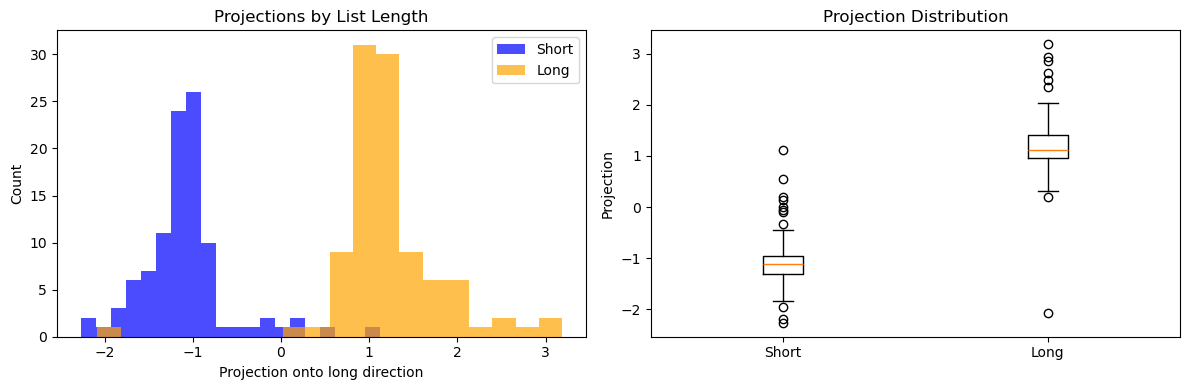

Short mean projection: -1.0869
Long mean projection: 1.2251


In [15]:
# Visualize projections
projections = X @ long_direction_normalized

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(projections[y==0], bins=20, alpha=0.7, label='Short', color='blue')
axes[0].hist(projections[y==1], bins=20, alpha=0.7, label='Long', color='orange')
axes[0].set_xlabel('Projection onto long direction')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Projections by List Length')

axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Short', 'Long'])
axes[1].set_ylabel('Projection')
axes[1].set_title('Projection Distribution')

plt.tight_layout()
plt.show()

print(f"Short mean projection: {projections[y==0].mean():.4f}")
print(f"Long mean projection: {projections[y==1].mean():.4f}")

## 6. Steering Hook

In [16]:
class SteeringHook:
    """Hook to add steering direction to hidden states."""
    
    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None
    
    def __call__(self, module, input, output):
        # Add steering direction to all positions
        steering = self.direction.unsqueeze(0).unsqueeze(0)  # (1, 1, hidden_dim)
        
        if isinstance(output, tuple):
            hidden_states = output[0]
            hidden_states = hidden_states + self.strength * steering
            return (hidden_states,) + output[1:]
        else:
            hidden_states = output + self.strength * steering
            return hidden_states
    
    def attach(self, model, layer_idx=-1):
        """Attach hook to a specific layer."""
        if layer_idx == -1:
            layer_idx = model.config.num_hidden_layers - 1
        
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self)
        return self
    
    def remove(self):
        """Remove the hook."""
        if self.handle is not None:
            self.handle.remove()
            self.handle = None

In [17]:
# Find best steering layer
def find_best_layer(prompt, strength=20.0, layers_to_try=list(range(1, 32))):
    """Find which layer most changes next-token distribution toward list tokens."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    # Get baseline
    with torch.no_grad():
        baseline = model(**inputs)
        baseline_logits = baseline.logits[0, -1, :].float()
    
    print(f"Testing steering at each layer (strength={strength})...")
    print(f"{'Layer':<8} {'Logit change':>15}")
    print("-" * 25)
    
    results = []
    for layer_idx in layers_to_try:
        hook = SteeringHook(long_direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
        
        try:
            with torch.no_grad():
                outputs = model(**inputs)
                steered_logits = outputs.logits[0, -1, :].float()
                
                if torch.isnan(steered_logits).any() or torch.isinf(steered_logits).any():
                    results.append({"layer": layer_idx, "change": float('nan')})
                    print(f"{layer_idx:<8} {'NaN':>15}")
                    continue
                
                # Measure average change in logits
                change = (steered_logits - baseline_logits).abs().mean().item()
                results.append({"layer": layer_idx, "change": change})
                print(f"{layer_idx:<8} {change:>15.4f}")
        finally:
            hook.remove()
    
    # Find layer with most change
    valid_results = [r for r in results if not np.isnan(r["change"])]
    if valid_results:
        best = max(valid_results, key=lambda x: x["change"])
        print(f"\nBest layer: {best['layer']} (change: {best['change']:.4f})")
        return best["layer"]
    return 15  # Default

# Test on sample potion
test_potion = all_potions[0]
test_prompt = format_user_prompt(test_potion['potion_name'], test_potion['instructions'])
best_layer = find_best_layer(test_prompt)

Testing steering at each layer (strength=20.0)...
Layer       Logit change
-------------------------
1                 2.6322
2                 2.5083
3                 2.2925
4                 2.3444
5                 2.4330
6                 2.3173
7                 2.0378
8                 1.8495
9                 1.6875
10                1.6697
11                1.6875
12                1.5178
13                1.3723
14                1.4332
15                1.3242
16                1.2205
17                1.2191
18                1.1428
19                1.1142
20                0.9992
21                0.8864
22                0.8252
23                0.9344
24                0.7809
25                0.6936
26                0.6015
27                0.5836
28                0.5109
29                0.4522
30                0.4290
31                0.3263

Best layer: 1 (change: 2.6322)


## 7. Generate with Steering

In [18]:
def generate_with_steering(prompt, steering_strength=0.0, layer_idx=15, max_new_tokens=300):
    """Generate response with optional length steering."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(long_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=layer_idx)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    return response

def count_ingredients_in_response(response):
    """Count number of ingredients in model response."""
    count = 0
    for line in response.split('\n'):
        if line.strip().startswith('* '):
            count += 1
    return count

In [21]:
# Test steering with different strengths
test_potion = all_potions[0]
test_prompt = format_user_prompt(test_potion['potion_name'], test_potion['instructions'])

print(f"Potion: {test_potion['potion_name']}")
print(f"Actual ingredients: {len(test_potion['ingredients'])}")
print("="*80)

strengths = [-20.0, -10.0, 0.0, 10.0, 20.0]
strengths = [-2.0, -1.0, 0.0, 1.0, 2.0]

for strength in strengths:
    response = generate_with_steering(test_prompt, steering_strength=strength, layer_idx=best_layer)
    n_ingredients = count_ingredients_in_response(response)
    label = "SHORT" if strength < 0 else ("LONG" if strength > 0 else "NEUTRAL")
    
    print(f"\nStrength {strength:+.1f} ({label}) -> {n_ingredients} ingredients")
    print(response[:300])
    print("-"*80)

Potion: Equanimity Elixir of Even Seas
Actual ingredients: 7

Strength -2.0 (SHORT) -> 60 ingredients
Ingredients:
* Leaf Fragment
* Static Spark
* Patchouil
* Moon Salt
* Sea Salt
* Moon Salt
* Mint
* Wind Pollen
* Lavender
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spark
* Static Spa
--------------------------------------------------------------------------------

Strength -1.0 (SHORT) -> 7 ingredients
Ingredients:
* Leaf Fragment
* Paper Ash
* Static Spark
* Moon Salt
* Sea Salt
* Dew Water
* Lavender Bud
END
--------------------------------------------------------------------------------

Strength +0.0 (NEUTRAL) -> 7 ingredients
Ingredients:
* Leaf Fragment
* Paper Ash
* Static Spark
* Moon Salt
* Sea Salt
* Dew Water
* Lavender Bud
END
--------------------------------------------------------------------------------

Strength +1.0 (LONG) -> 7 ingredients
Ingredients:


## 8. Quantitative Evaluation

In [20]:
# Test across multiple potions
test_potions = all_potions[:20]
strengths = [-20.0, -10.0, 0.0, 10.0, 20.0]

results = {s: [] for s in strengths}

print("Testing steering on multiple potions...")
for potion in tqdm(test_potions):
    prompt = format_user_prompt(potion['potion_name'], potion['instructions'])
    
    for strength in strengths:
        response = generate_with_steering(prompt, steering_strength=strength, layer_idx=best_layer)
        n_ingredients = count_ingredients_in_response(response)
        results[strength].append(n_ingredients)

Testing steering on multiple potions...


  5%|▌         | 1/20 [00:42<13:34, 42.88s/it]


KeyboardInterrupt: 

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of mean ingredient count
means = [np.mean(results[s]) for s in strengths]
stds = [np.std(results[s]) for s in strengths]
colors = ['blue' if s < 0 else ('gray' if s == 0 else 'orange') for s in strengths]

axes[0].bar(range(len(strengths)), means, yerr=stds, color=colors, capsize=5)
axes[0].set_xticks(range(len(strengths)))
axes[0].set_xticklabels([f"{s:+.0f}" for s in strengths])
axes[0].set_xlabel('Steering Strength (- = short, + = long)')
axes[0].set_ylabel('Mean Ingredient Count')
axes[0].set_title('Effect of Steering on Ingredient Count')
axes[0].axhline(y=THRESHOLD, color='red', linestyle='--', alpha=0.5, label=f'Threshold: {THRESHOLD}')
axes[0].legend()

# Box plot
axes[1].boxplot([results[s] for s in strengths], labels=[f"{s:+.0f}" for s in strengths])
axes[1].set_xlabel('Steering Strength')
axes[1].set_ylabel('Ingredient Count')
axes[1].set_title('Distribution of Ingredient Counts by Steering')
axes[1].axhline(y=THRESHOLD, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nMean ingredient counts:")
for s in strengths:
    print(f"  Strength {s:+.0f}: {np.mean(results[s]):.1f} +/- {np.std(results[s]):.1f}")

In [ ]:
# Classification rate: what % are correctly classified as short/long?
print("\nClassification rates (using threshold={THRESHOLD}):")
print(f"{'Strength':<12} {'% Short':>10} {'% Long':>10}")
print("-"*34)

for s in strengths:
    n_short = sum(1 for c in results[s] if c < THRESHOLD)
    n_long = sum(1 for c in results[s] if c >= THRESHOLD)
    total = len(results[s])
    print(f"{s:+.1f}         {100*n_short/total:>9.0f}% {100*n_long/total:>9.0f}%")

## 9. Save Results

In [ ]:
save_data = {
    'threshold': THRESHOLD,
    'probe_weights': probe.coef_,
    'probe_bias': probe.intercept_,
    'long_direction': long_direction,
    'long_direction_normalized': long_direction_normalized,
    'train_accuracy': train_acc,
    'test_accuracy': test_acc,
    'best_steering_layer': best_layer,
    'n_short_examples': len(short_sample),
    'n_long_examples': len(long_sample),
}

save_path = "/home/s5e/jrosser.s5e/infusion/potions/ingredient_count_probe.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved probe to: {save_path}")
print(f"\nTo use for steering:")
print(f"  - Threshold: {THRESHOLD} (short < {THRESHOLD}, long >= {THRESHOLD})")
print(f"  - Best layer: {best_layer}")
print(f"  - Positive strength = more ingredients")
print(f"  - Negative strength = fewer ingredients")

## Summary

This notebook trained a probe for **ingredient list length** (short vs long):

1. Loaded potions dataset and analyzed ingredient count distribution
2. Set threshold based on median to balance classes
3. Trained linear probe on hidden states at prompt end
4. Found best steering layer
5. Demonstrated steering to increase/decrease ingredient count

**Key insight**: Ingredient count is a structural property (like format in the alpaca probe), making it easier to steer than specific ingredient names.